In [16]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import iterate
importlib.reload(iterate)
from iterate import iterate, iterate_postrans, h_fixed_points, hprime, BETA

np.set_printoptions(suppress=True)

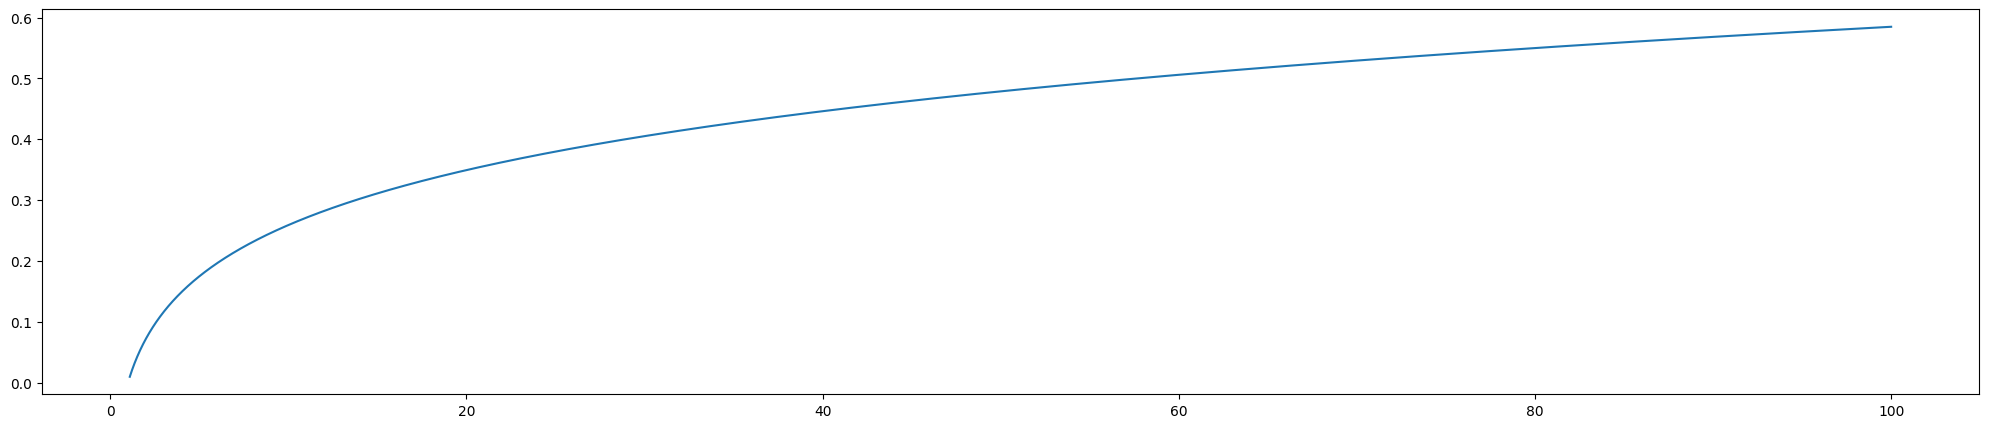

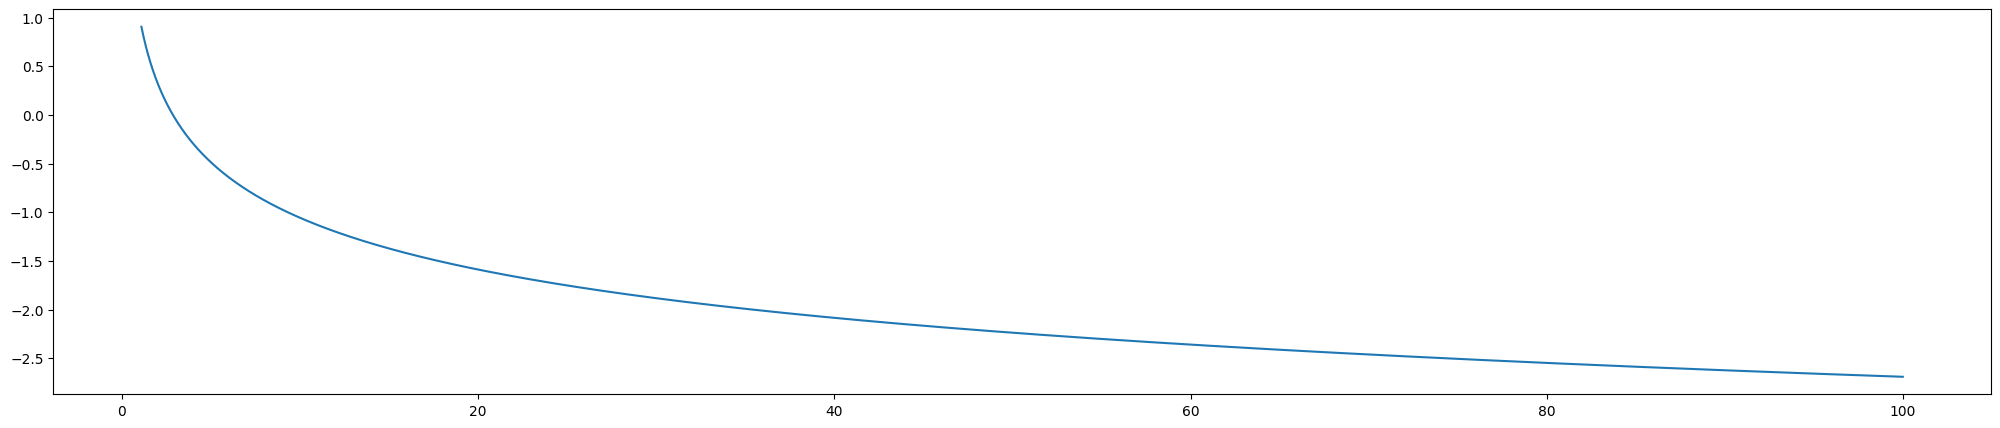

In [17]:
fixed_pts = [[l, h_fixed_points(l)] for l in np.arange(1.1, 100, 0.01)]
plt.figure(figsize=(25, 5))
sns.lineplot(x=[pt[0] for pt in fixed_pts], y=[pt[1] for pt in fixed_pts])
plt.show()

fixed_pts_prime = [[p[0], hprime(p[0], p[1])] for p in fixed_pts]
plt.figure(figsize=(25, 5))
sns.lineplot(x=[pt[0] for pt in fixed_pts_prime], y=[pt[1] for pt in fixed_pts_prime])
plt.show()

In [18]:
fixed_pts = [[l, h_fixed_points(l)] for l in np.arange(9, 10, 0.001)]
fixed_pts_prime = [[p[0], hprime(p[0], p[1])] for p in fixed_pts]

for p in fixed_pts_prime:
    if np.isclose(p[1], -1, atol=1e-5):
        print(p)

[np.float64(9.312999999999827), np.float64(-0.9999806082944215)]


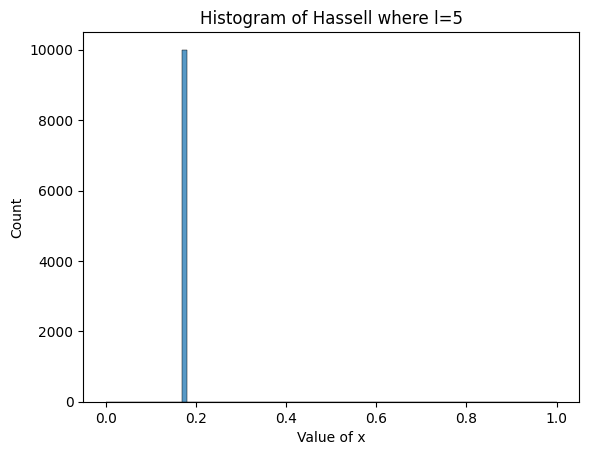

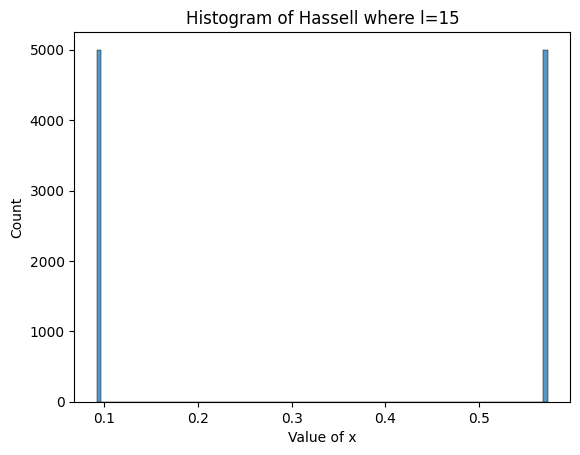

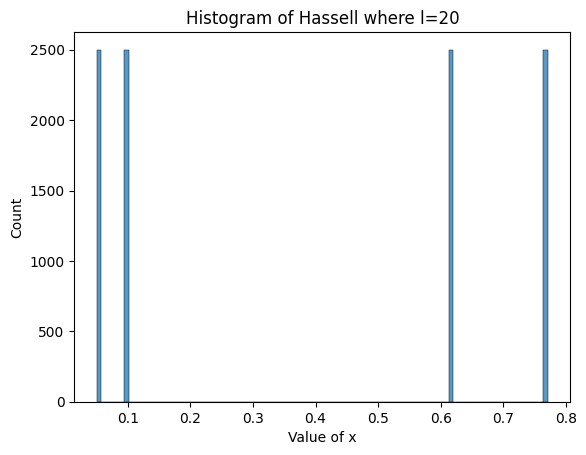

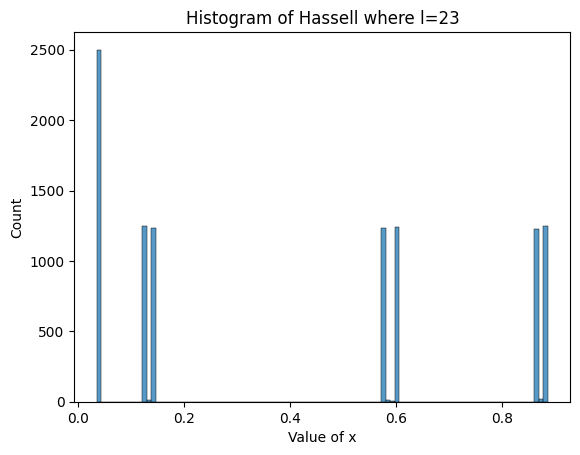

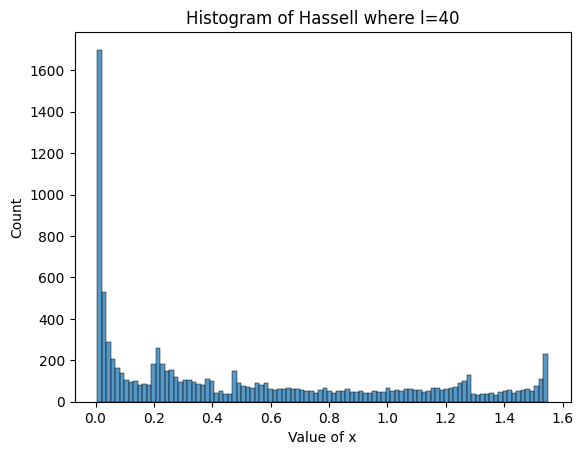

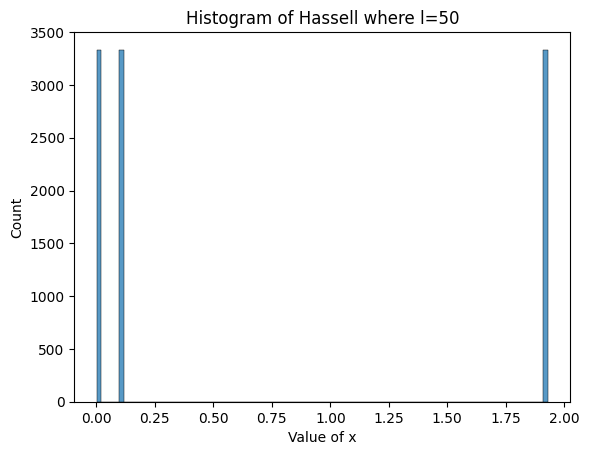

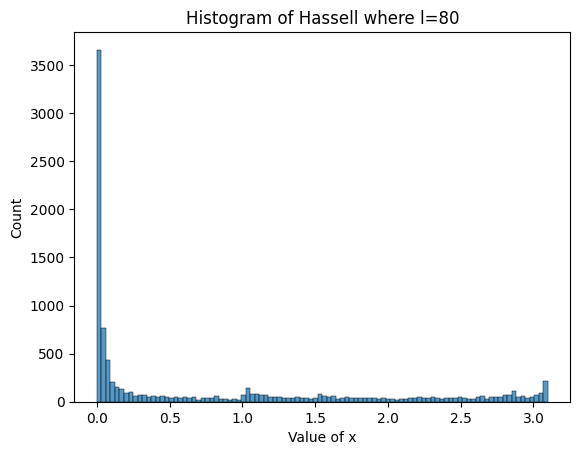

In [19]:
for l in [5, 15, 20, 23, 40, 50, 80]:
    res = iterate_postrans(l, 0.5, 10000)[1]
    sns.histplot(res, bins=100, binrange=(0, 1) if l == 5 else None)
    plt.title(f"Histogram of Hassell where l={l}")
    plt.xlabel("Value of x")
    plt.show()

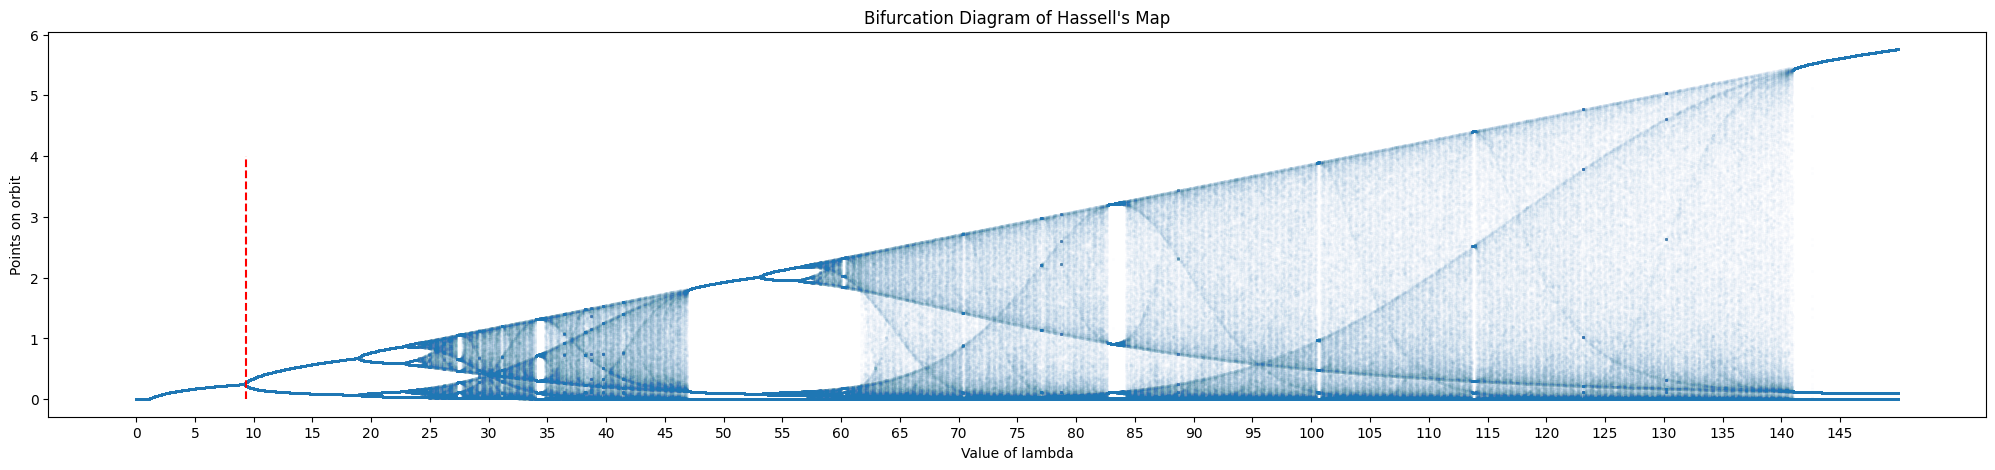

In [20]:
xs = []
ys = []
for l in np.arange(0, 150, 0.1):
    iterates = 1000
    xs.extend([l] * iterates)
    ys.extend(iterate_postrans(l, 0.5, iterates)[1])

plt.figure(figsize=(25, 5))
sns.scatterplot(x=xs, y=ys, alpha=0.01, s=5)
plt.title("Bifurcation Diagram of Hassell's Map")
plt.xticks(np.arange(0, 150, 5))
plt.vlines([9.313], [0], [4], colors="red", linestyles="dashed")
plt.xlabel("Value of lambda")
plt.ylabel("Points on orbit")
plt.show()

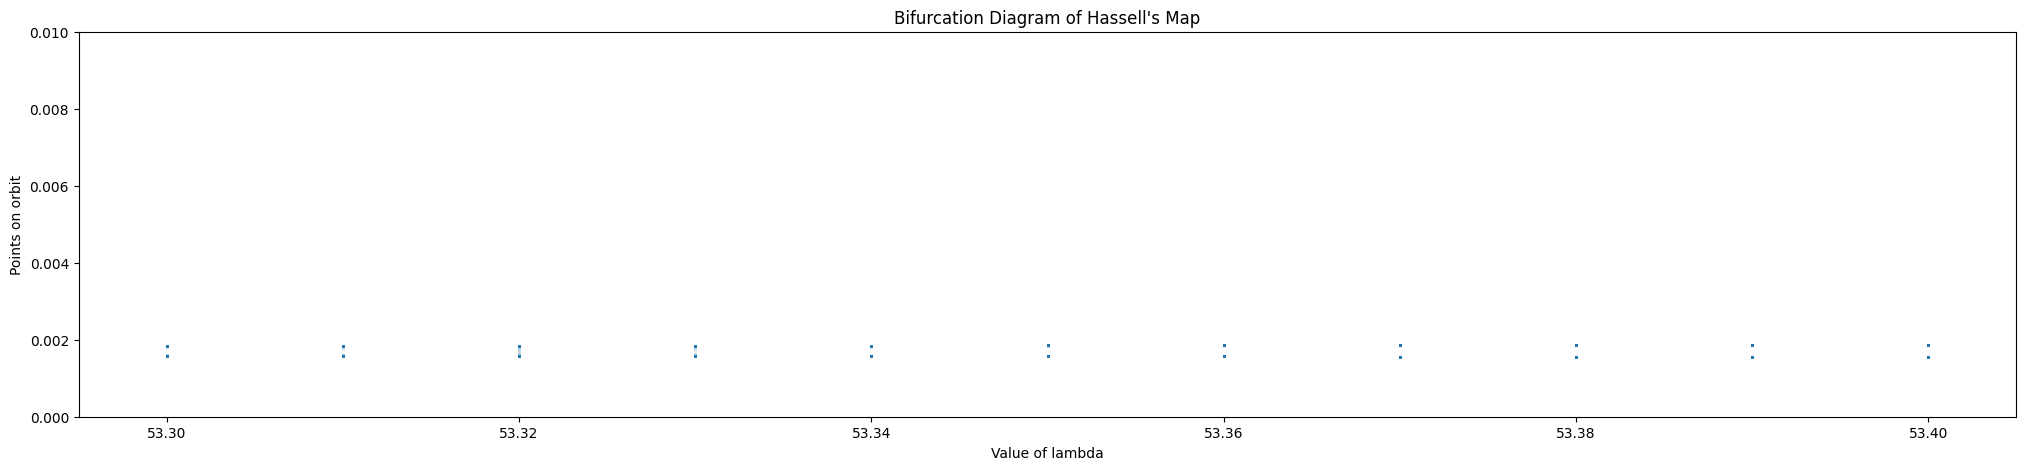

In [21]:
xs = []
ys = []
for l in np.arange(53.3, 53.4, 0.01):
    iterates = 2000
    xs.extend([l] * iterates)
    ys.extend(iterate_postrans(l, 0.5, iterates)[1])

plt.figure(figsize=(25, 5))
sns.scatterplot(x=xs, y=ys, alpha=0.01, s=5)
plt.ylim(0, 0.01)
# plt.xticks(np.arange(50, 60, 0.1))
plt.title("Bifurcation Diagram of Hassell's Map")
plt.xlabel("Value of lambda")
plt.ylabel("Points on orbit")
plt.show()

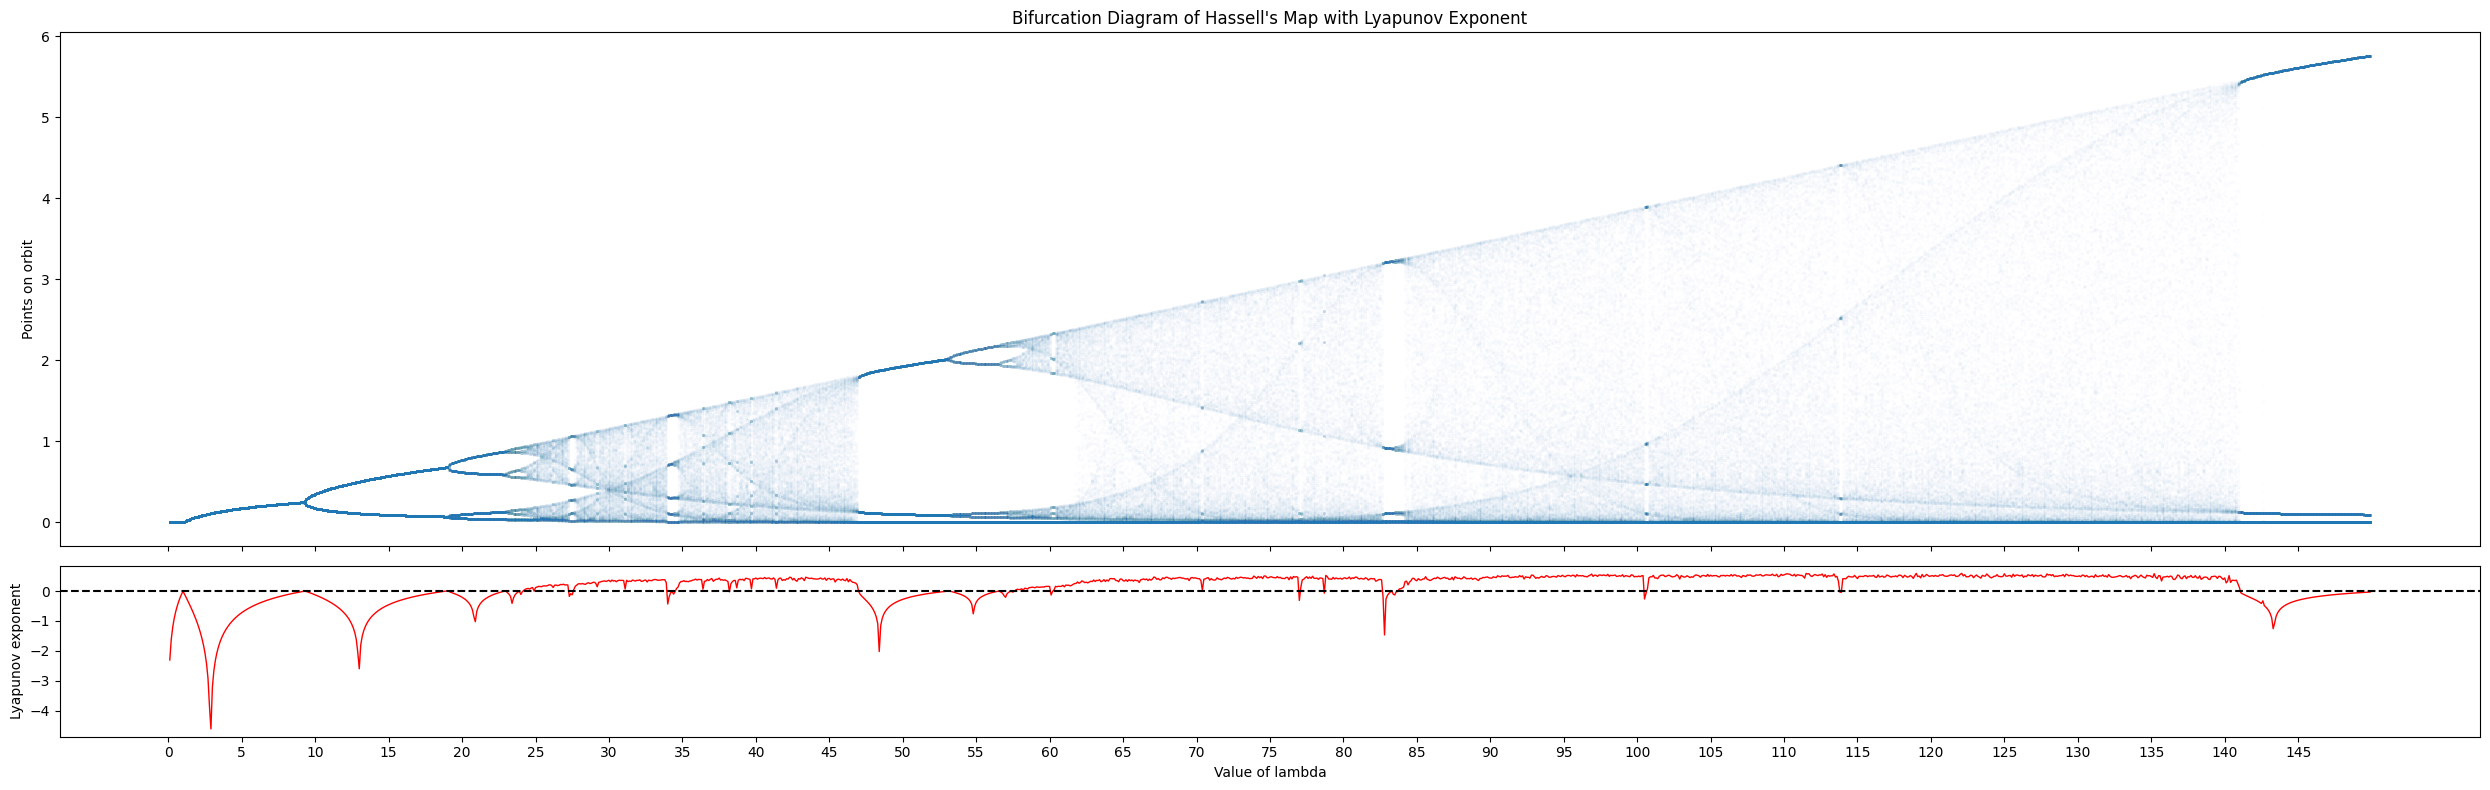


Possible transition points:
lambda=1.00, lyap=-0.005872, event=same side / bounce
lambda=9.20, lyap=-0.009913, event=same side / bounce
lambda=9.30, lyap=-0.004092, event=same side / bounce
lambda=18.80, lyap=-0.007416, event=same side / bounce
lambda=18.90, lyap=-0.000783, event=same side / bounce
lambda=19.00, lyap=0.005318, event=sign shift
lambda=19.10, lyap=-0.009592, event=sign shift
lambda=22.90, lyap=-0.002161, event=same side / bounce
lambda=23.90, lyap=-0.005309, event=same side / bounce
lambda=24.20, lyap=0.021920, event=sign shift
lambda=24.90, lyap=-0.000884, event=sign shift
lambda=25.00, lyap=0.115444, event=sign shift
lambda=27.30, lyap=-0.179121, event=sign shift
lambda=27.60, lyap=0.044820, event=sign shift
lambda=34.00, lyap=-0.432027, event=sign shift
lambda=34.60, lyap=0.085291, event=sign shift
lambda=38.20, lyap=-0.027747, event=sign shift
lambda=38.30, lyap=0.242379, event=sign shift
lambda=47.00, lyap=-0.016917, event=sign shift
lambda=53.00, lyap=-0.006488, e

In [ ]:
xs = []
ys = []
lyap_x = []
lyap_y = []

b = BETA
eps = 1e-12
near_zero_events = []

zero_tol = 0.01     #Tolerance for near zero events
prev_lyap = None
prev_i = None

for i in np.arange(0.1, 150, 0.1):
    orbit_pts = 300
    orbit = iterate_postrans(i, 0.5, orbit_pts)[1]

    xs.extend([i] * orbit_pts)
    ys.extend(orbit)

    lyap_sum = 0.0
    for x in orbit:
        deriv = i * (1 + (1 - b) * x) / (1 + x)**(b + 1)
        lyap_sum += np.log(abs(deriv) + eps)

    curr_lyap = lyap_sum / orbit_pts

    lyap_x.append(i)
    lyap_y.append(curr_lyap)

    # --- simple event check ---
    if abs(curr_lyap) < zero_tol:
        event_type = "near-zero"
        if prev_lyap is not None:
            if np.sign(prev_lyap) != 0 and np.sign(curr_lyap) != 0:
                if np.sign(prev_lyap) != np.sign(curr_lyap):
                    event_type = "sign shift"
                else:
                    event_type = "same side / bounce"
            elif prev_lyap != 0:
                event_type = "near-zero from " + ("positive" if prev_lyap > 0 else "negative")

        near_zero_events.append((i, curr_lyap, event_type))

    elif prev_lyap is not None and np.sign(prev_lyap) != np.sign(curr_lyap):
        near_zero_events.append((i, curr_lyap, "sign shift"))

    prev_lyap = curr_lyap
    prev_i = i

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(25, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.scatterplot(x=xs, y=ys, alpha=0.01, s=5, ax=ax1)
ax1.set_title("Bifurcation Diagram of Hassell's Map with Lyapunov Exponent")
ax1.set_ylabel("Points on orbit")
ax1.set_xticks(np.arange(0, 150, 5))

ax2.plot(lyap_x, lyap_y, color="red", linewidth=1)
ax2.axhline(0, color="black", linestyle="dashed")
ax2.set_xlabel("Value of lambda")
ax2.set_ylabel("Lyapunov exponent")

plt.tight_layout()
plt.show()

print("\nPossible transition points:")
for i, val, event_type in near_zero_events:
    print(f"lambda={i:.2f}, lyap={val:.6f}, event={event_type}")